# 🧠 Digit Classification using Convolutional Neural Network (CNN)
Deep learning model optimized for image-based classification.

In [1]:
import tensorflow as tf 
from tensorflow import keras
import matplotlib.pyplot as plt 
%matplotlib inline
import numpy as np

## 📊 Dataset
- MNIST handwritten digits  
- 28×28 grayscale images  
- 10 classes (0–9)

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
len(X_train)

60000

In [4]:
len(X_test)

10000

## ⚙️ Preprocessing
- Normalize pixel values (0–1)  
- Reshape to (28, 28, 1) for CNN input  

In [5]:
X_train = X_train / 255
X_test = X_test / 255

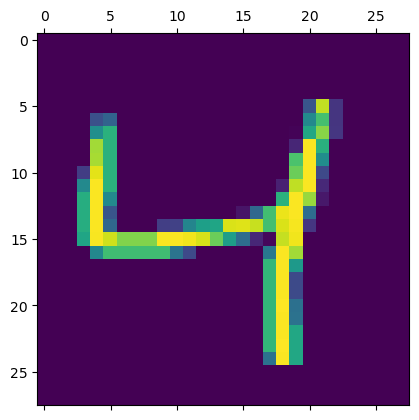

In [6]:
plt.matshow(X_train[2])
plt.show()

In [7]:
X_train_flat = X_train.reshape(len(X_train),28*28)
X_test_flat = X_test.reshape(len(X_test),28*28)
X_test_flat.shape

(10000, 784)

In [8]:
X_train.shape

(60000, 28, 28)

In [9]:
y_train[0]

5

## 🏗️ Model (CNN)
- Convolution layers (feature extraction)  
- Pooling layers (downsampling)  
- Fully connected layers (classification)
## 🧠 Why CNN?
- Preserves spatial structure  
- Detects edges, shapes, patterns  
- Best suited for image data 

In [10]:
from tensorflow.keras import models,layers

In [11]:
cnn = models.Sequential([
    layers.Conv2D(filters =28, kernel_size = (4, 4), activation = 'relu', input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters =56, kernel_size = (4, 4), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(100, activation = 'relu'),
    layers.Dense(10, activation = 'sigmoid')
])

C:\Users\HEMANTH KUMAR K\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 🤖 Training
- Optimizer: Adam  
- Loss: Sparse categorical crossentropy  
- Trained over multiple epochs 

In [12]:
cnn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
cnn.fit(X_train, y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9047 - loss: 0.3150
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9849 - loss: 0.0488
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9907 - loss: 0.0302
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9930 - loss: 0.0210
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9938 - loss: 0.0184
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9957 - loss: 0.0127
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9970 - loss: 0.0097
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9973 - loss: 0.0077
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9967 - loss: 0.0091
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9969 - loss: 0.0080


## 📈 Results
- Accuracy: ~98–99%  
- Highest performance among all models  

In [13]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9877 - loss: 0.0493


[0.04315576329827309, 0.9898999929428101]

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = cnn.predict(X_test)
y_pred_class = [np.argmax(i) for i in y_pred]
print(classification_report(y_test, y_pred_class))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.97      1.00      0.98      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.98      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [15]:
cn = confusion_matrix(y_test, y_pred_class)

In [18]:
cnn.save("models/cnn_model.h5")

## 🔍 Predictions
- Most digits classified correctly  
- Strong performance even on complex patterns  

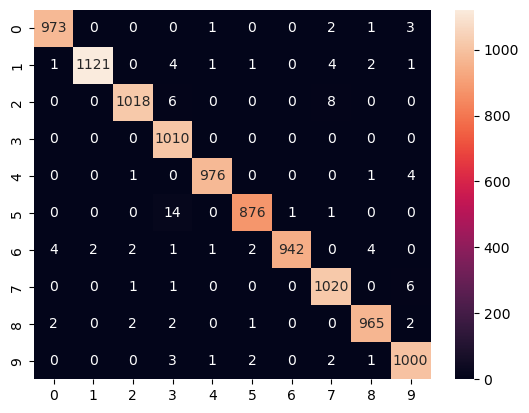

In [16]:
import seaborn as sn
cm = sn.heatmap(cn,annot = True, fmt = 'd')
plt.show()

## ⚖️ Comparison

| Model               | Accuracy |
|--------------------|---------|
| Logistic Regression| ~96%    |
| ANN                | ~98%    |
| CNN                | ~99%    |

### 🧠 Insight
CNN outperforms others due to spatial feature learning.

## 🏁 Conclusion
CNN achieves the best performance and is the most suitable model for image classification tasks.